In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


mushrooms = pd.read_csv('mushrooms.csv')

In [13]:
# Separate Features (X) and Target Variable (y)
# 'class' column contains 'p' (poisonous) or 'e' (edible)
X = mushrooms.drop('class', axis=1)
y = mushrooms['class']

if 'veil-type' in X.columns:
    X = X.drop('veil-type', axis=1)



In [14]:
# Convert Categorical Text Columns to Numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X)

# Spliting the data into Training and Testing sets (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.30, random_state=101)

In [15]:
# Initialize and Train the Decision Tree Classifier
dtree = DecisionTreeClassifier(max_depth=3, random_state=101)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=101)

--- Mushroom Model Evaluation ---
Accuracy Score: 0.9864643150123051

Confusion Matrix:
[[1244   30]
 [   3 1161]]

Classification Report:
              precision    recall  f1-score   support

           e       1.00      0.98      0.99      1274
           p       0.97      1.00      0.99      1164

    accuracy                           0.99      2438
   macro avg       0.99      0.99      0.99      2438
weighted avg       0.99      0.99      0.99      2438



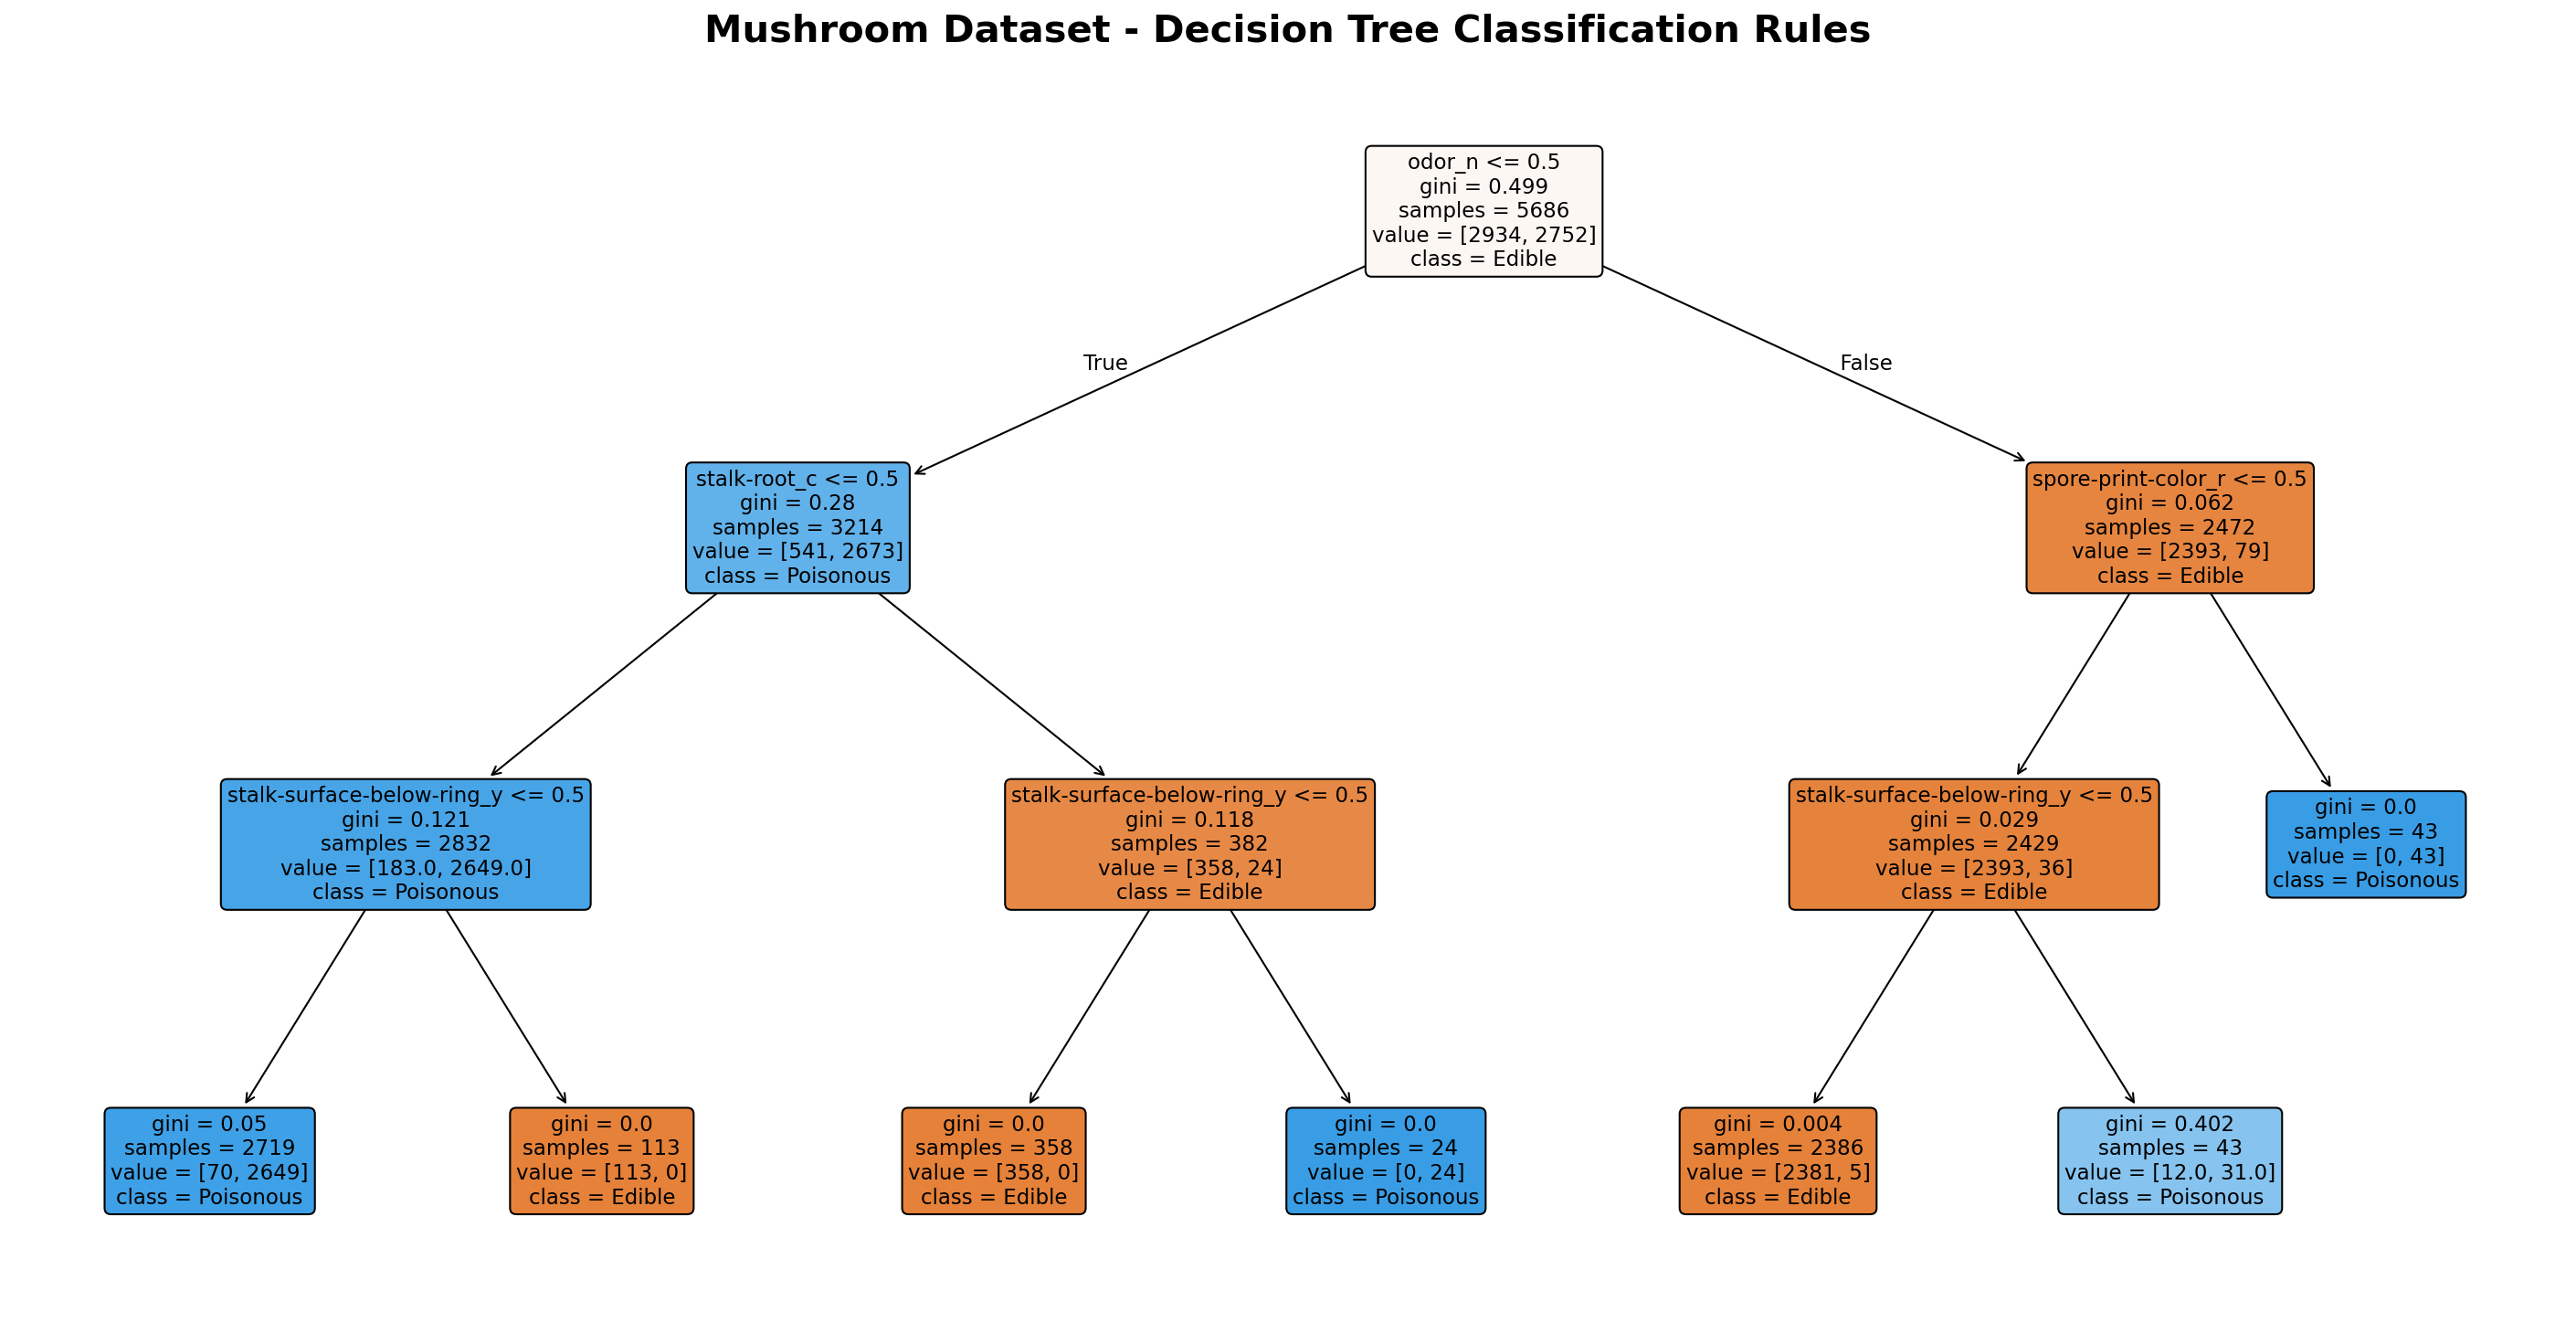

In [16]:
#Make Predictions and Evaluate Model Performance
dtree_pred = dtree.predict(X_test)

print("--- Mushroom Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test, dtree_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dtree_pred))
print("\nClassification Report:")
print(classification_report(y_test, dtree_pred))

# Decision Tree Diagram
plt.figure(figsize=(24, 12), dpi=150)  # High-resolution wide canvas

plot_tree(
    dtree, 
    feature_names=X_encoded.columns, 
    class_names=['Edible', 'Poisonous'], 
    filled=True,          # Colors the nodes based on class certainty
    rounded=True,         # Rounds node boxes
    fontsize=11           # Legible font sizes for text inside boxes
)

plt.title("Mushroom Dataset - Decision Tree Classification Rules", fontsize=20, weight='bold')
plt.show()